<a href="https://colab.research.google.com/github/officialadhyayansaha-eng/IITBDV-Recruitment-Hackathon/blob/main/Perception/Distance_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
uploaded = files.upload()

Saving YOLOv11s-Carmaker.pt to YOLOv11s-Carmaker (2).pt


In [1]:
!pip install ultralytics

In [4]:
from google.colab import files
uploaded = files.upload()

Saving image.png to image (1).png


In [2]:
from ultralytics import YOLO
import torch
model=YOLO('YOLOv11s-Carmaker.pt')
result=model('image.png')


image 1/1 /content/image.png: 384x640 3 Blues, 2 Small Oranges, 3 Yellows, 508.7ms
Speed: 10.4ms preprocess, 508.7ms inference, 32.3ms postprocess per image at shape (1, 3, 384, 640)


In [3]:
boxes=result[0].boxes.xyxy

In [4]:
distances=[]
H_Real=30
F=1000
for box in boxes:
  x1,y1,x2,y2=box[0],box[1],box[2],box[3]
  h=y2-y1
  d=(H_Real*F)/h
  distances.append(d/100)
distances


[tensor(4.0438),
 tensor(3.5165),
 tensor(2.9619),
 tensor(4.0359),
 tensor(4.4596),
 tensor(3.6453),
 tensor(3.4807),
 tensor(2.6897)]

(np.float64(-0.5), np.float64(1279.5), np.float64(719.5), np.float64(-0.5))

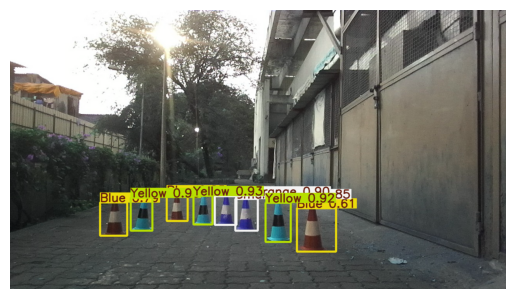

In [5]:
annotated = result[0].plot()
import matplotlib.pyplot as plt

plt.imshow(annotated)
plt.axis("off")

In [6]:
import cv2

img = cv2.imread("image.png")

In [9]:
for box, d in zip(boxes, distances):
    x1, y1, x2, y2 = map(int, box)
    label = f"Dist: {d:.2f} m"
    cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,0), 2)
    cv2.putText(img,label,(x1, y1-10),cv2.FONT_HERSHEY_SIMPLEX,0.6,(0,255,0),2)

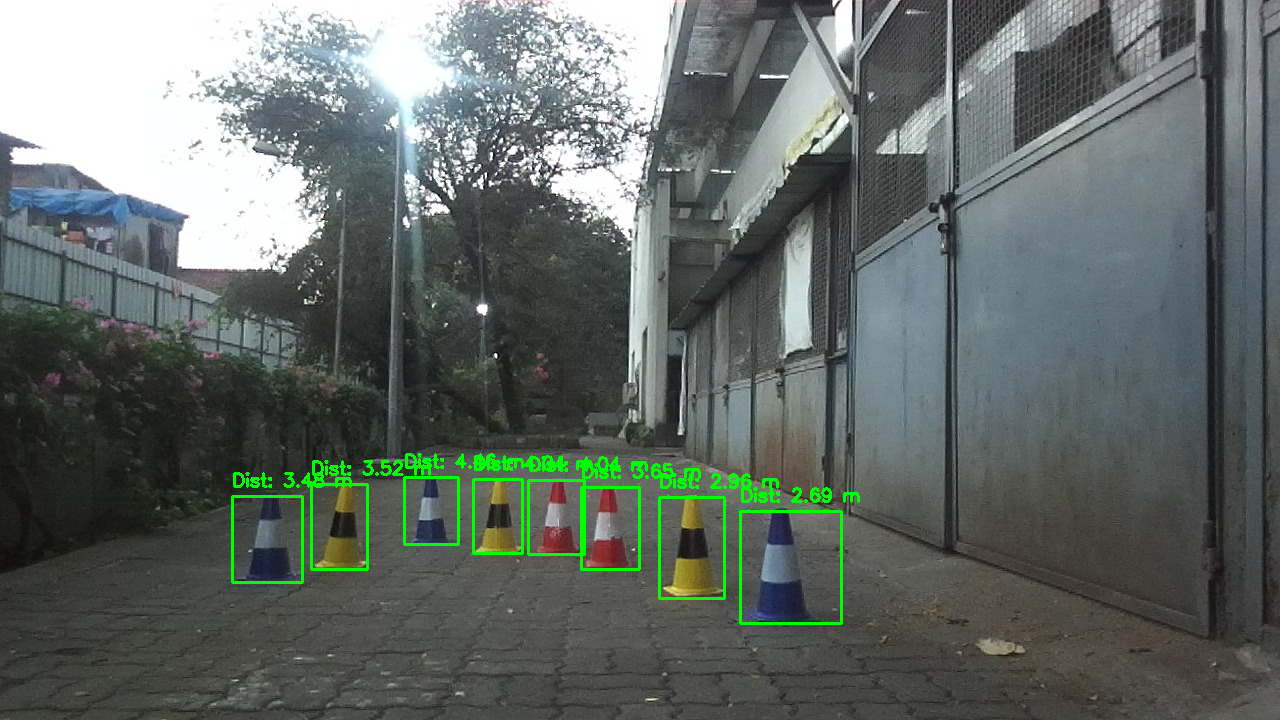

In [10]:
from google.colab.patches import cv2_imshow
cv2_imshow(img)